# Sentiment Comparison: Llama Output vs LLM Output vs Gold

Compares predictions from `llama_output/` and `llm_output/sentiment.csv` against gold labels.

**Alignment:** Uses `INPUT_CSV` (default: sentiment_input_1000.csv) as source of truth. Row i has gold=sentiment_ground_truth[i], llama key "i", LLM id i+1. **Important:** For correct comparison, both Llama and LLM must have been run on the *same* input file. If LLM was run on sentiment_input.csv (20000) and Llama on sentiment_input_1000.csv, the first 50 samples differ—use matching outputs.

In [12]:
import os
import json
import glob
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import custom_datasets

# Alignment: use the SAME input for both Llama and LLM. Set LLM output that matches INPUT_CSV.
INPUT_CSV = "llm_input/sentiment_input_1000.csv"  # Llama 50 likely from first 50 of this
LLM_OUTPUT_CSV = "llm_output/sentiment_1000.csv"       # If this is from sentiment_input.csv (20k), use a 1000-row file for correct alignment

In [13]:
# Gold labels (same order as sentiment_data)
sentiment_data = custom_datasets.sentiment_data
sentiment_ground_truth = custom_datasets.sentiment_ground_truth
gold = [g.strip().lower() for g in sentiment_ground_truth]
labels_cls = ["negative", "positive"]
n_gold = len(gold)
print(f"Gold: {n_gold} samples from sentiment_ground_truth")

# Verify gold aligns with input: sentiment_input_1000 row i = sentiment_data[i]
if os.path.exists(INPUT_CSV):
    df_in = pd.read_csv(INPUT_CSV, nrows=5)
    for i in range(min(3, len(df_in))):
        in_text = str(df_in.iloc[i]["text"])[:50]
        data_text = sentiment_data[i][:50] if i < len(sentiment_data) else "N/A"
        match = "OK" if in_text.strip() == data_text.strip() else "MISMATCH"
        print(f"  Row {i}: input text starts '{in_text}...' | sentiment_data[{i}] '{data_text}...' [{match}]")

Gold: 10000 samples from sentiment_ground_truth
  Row 0: input text starts 'a little better than sorcerer 's stone . ...' | sentiment_data[0] 'a little better than sorcerer 's stone . ...' [OK]
  Row 1: input text starts 'looking for a return ticket to realism ...' | sentiment_data[1] 'looking for a return ticket to realism ...' [OK]
  Row 2: input text starts 'the shameless self-caricature of ` analyze this ' ...' | sentiment_data[2] 'the shameless self-caricature of ` analyze this ' ...' [OK]


In [14]:
# Load Llama output (JSON: {"0":"positive", "1":"negative", ...})
def load_llama_predictions(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        return []
    n = max((int(k) for k in data.keys() if str(k).isdigit()), default=-1) + 1
    preds = []
    for i in range(n):
        val = str(data.get(str(i), "positive")).strip().lower()
        preds.append("negative" if ("neg" in val or val == "negative") else "positive")
    return preds

llama_files = sorted(glob.glob("llama_output/*.json"))
llama_preds = []
if llama_files:
    llama_preds = load_llama_predictions(llama_files[0])
    print(f"Llama: loaded {llama_files[0]}, {len(llama_preds)} predictions")
else:
    print("Llama: no JSON files in llama_output/")

n_llama = len(llama_preds)

Llama: loaded llama_output/test1.json, 50 predictions


In [15]:
# Load LLM output (CSV: id,label). Id i = prediction for row (i-1) of the input used.
llm_id_to_label = {}
if os.path.exists(LLM_OUTPUT_CSV):
    df = pd.read_csv(LLM_OUTPUT_CSV)
    for _, row in df.iterrows():
        uid = int(row["id"])
        val = str(row["label"]).strip().lower()
        lbl = "negative" if ("neg" in val or val == "negative") else "positive"
        llm_id_to_label[uid] = lbl
    print(f"LLM: loaded {LLM_OUTPUT_CSV}, {len(llm_id_to_label)} predictions")
else:
    print(f"LLM: {LLM_OUTPUT_CSV} not found")

LLM: loaded llm_output/sentiment_1000.csv, 1000 predictions


In [16]:
# Align using INPUT_CSV: row i has id=i+1, text=sentiment_data[i], gold=sentiment_ground_truth[i]
# Llama keys "0","1",... = row 0,1,...; LLM id (i+1) = row i
df_input = pd.read_csv(INPUT_CSV) if os.path.exists(INPUT_CSV) else None
n_input = len(df_input) if df_input is not None else n_gold

n = min(n_input, n_gold, n_llama) if llama_preds else min(n_input, n_gold)
# LLM: use predictions for ids 1..n (input row i has id i+1)
llm_aligned = [llm_id_to_label.get(i + 1, "positive") for i in range(n)] if llm_id_to_label else []
gold_aligned = gold[:n]
llama_aligned = llama_preds[:n] if llama_preds else []

# Warn if LLM was run on different input (different row counts)
n_llm = len(llm_id_to_label)
if n_llm != n_input and n_llm > 0:
    print(f"[!] LLM has {n_llm} rows, input has {n_input}. If they used different input files, alignment may be wrong.")

print(f"Aligned: {n} samples (gold[0:{n}], llama[0:{n}], LLM ids 1..{n})")

Aligned: 50 samples (gold[0:50], llama[0:50], LLM ids 1..50)


In [17]:
# Spot-check alignment (first 5 rows)
print("Sample alignment (row 0-4):")
print("idx | text_snippet                    | gold      | llama     | llm")
print("-" * 80)
for i in range(min(5, n)):
    text_snip = (sentiment_data[i][:35] + "..") if len(sentiment_data[i]) > 35 else sentiment_data[i]
    g = gold_aligned[i] if i < len(gold_aligned) else "-"
    la = llama_aligned[i] if i < len(llama_aligned) else "-"
    lm = llm_aligned[i] if i < len(llm_aligned) else "-"
    print(f"{i:3d} | {text_snip:32s} | {g:9s} | {la:9s} | {lm}")

Sample alignment (row 0-4):
idx | text_snippet                    | gold      | llama     | llm
--------------------------------------------------------------------------------
  0 | a little better than sorcerer 's st.. | positive  | negative  | positive
  1 | looking for a return ticket to real.. | negative  | negative  | negative
  2 | the shameless self-caricature of ` .. | negative  | negative  | negative
  3 | director paul cox 's unorthodox , a.. | positive  | positive  | positive
  4 | stevens ' vibrant creative instinct.. | positive  | positive  | positive


## Per-class metrics

In [18]:
def metrics_table(y_true, y_pred):
    P, R, F1, S = precision_recall_fscore_support(y_true, y_pred, labels=labels_cls, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    rows = []
    for i, lbl in enumerate(labels_cls):
        rows.append({"Class": lbl, "Precision": round(P[i], 4), "Recall": round(R[i], 4), "F1": round(F1[i], 4), "Support": int(S[i])})
    P_m, R_m, F1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    rows.append({"Class": "Macro avg", "Precision": round(P_m, 4), "Recall": round(R_m, 4), "F1": round(F1_m, 4), "Support": len(y_true)})
    df = pd.DataFrame(rows)
    print(f"Accuracy: {acc:.4f} ({int(acc*len(y_true))}/{len(y_true)})")
    return df

if llama_aligned:
    print("### Llama vs Gold")
    display(metrics_table(gold_aligned, llama_aligned))

if llm_aligned:
    print("\n### LLM vs Gold")
    display(metrics_table(gold_aligned, llm_aligned))

### Llama vs Gold
Accuracy: 0.8800 (44/50)


,Class,Precision,Recall,F1,Support
0,negative,0.7619,0.9412,0.8421,17
1,positive,0.9655,0.8485,0.9032,33
2,Macro avg,0.8637,0.8948,0.8727,50



### LLM vs Gold
Accuracy: 0.9800 (49/50)


,Class,Precision,Recall,F1,Support
0,negative,0.9444,1.0000,0.9714,17
1,positive,1.0000,0.9697,0.9846,33
2,Macro avg,0.9722,0.9848,0.9780,50


## Confusion matrices

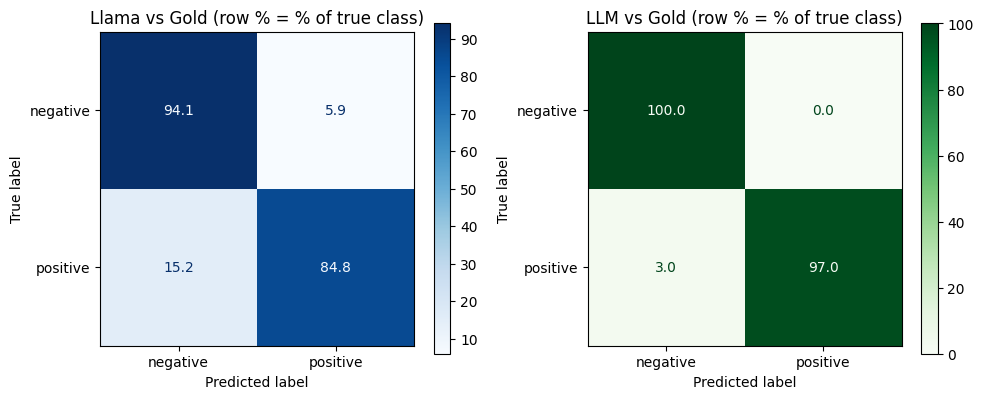

In [19]:
def plot_cm_pct(ax, y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=labels_cls)
    cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    disp = ConfusionMatrixDisplay(cm_pct * 100, display_labels=labels_cls)
    disp.plot(ax=ax, cmap=cmap, values_format=".1f")
    ax.set_title(f"{title} (row % = % of true class)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if llama_aligned:
    plot_cm_pct(axes[0], gold_aligned, llama_aligned, "Llama vs Gold", "Blues")
else:
    axes[0].text(0.5, 0.5, "No Llama data", ha="center", va="center", transform=axes[0].transAxes)

if llm_aligned:
    plot_cm_pct(axes[1], gold_aligned, llm_aligned, "LLM vs Gold", "Greens")
else:
    axes[1].text(0.5, 0.5, "No LLM data", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()